# Guided Onboarding Experiment Analysis

## Experiment Overview

FlowPilot tested a guided onboarding experience designed to help new workspace owners move through three important early product actions:

**Connect Integration → Choose Workflow Template → Run First Workflow**

The experiment compared:

- **Control:** Existing onboarding experience
- **Treatment:** Guided onboarding experience

### Primary Metric
- Activation rate

### Secondary Metrics
- 7-day retention
- 30-day retention
- Integration connection
- Template adoption
- Paid conversion

### Guardrail Metrics
- Support ticket rate
- Cancellation rate

The goal of this analysis is to determine whether the treatment improved user outcomes enough to justify a broader rollout.

## 1. Setup and Imports

This notebook uses Python to evaluate the statistical reliability of the experiment results previously prepared in SQL.

The analysis includes:

- absolute and relative lift
- two-proportion z-tests
- confidence intervals
- statistical power
- required sample size
- launch recommendation

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

## 2. Experiment Results

The SQL analysis produced 588 experiment participants:

- **Control:** 292 users
- **Treatment:** 296 users

The table below contains the number of users who achieved each metric in both experiment variants.

In [19]:
experiment_data = pd.DataFrame({
    "metric": [
        "Activation",
        "7-Day Retention",
        "30-Day Retention",
        "Integration Connection",
        "Template Adoption",
        "Paid Conversion",
        "Support Ticket Rate",
        "Cancellation Rate"
    ],
    "control_successes": [
        104,
        113,
        76,
        153,
        82,
        33,
        1,
        5
    ],
    "control_total": [
        292,
        292,
        292,
        292,
        292,
        292,
        292,
        292
    ],
    "treatment_successes": [
        109,
        130,
        79,
        143,
        74,
        37,
        0,
        5
    ],
    "treatment_total": [
        296,
        296,
        296,
        296,
        296,
        296,
        296,
        296
    ]
})

experiment_data

,metric,control_successes,control_total,treatment_successes,treatment_total
0,Activation,104,292,109,296
1,7-Day Retention,113,292,130,296
2,30-Day Retention,76,292,79,296
3,Integration Connection,153,292,143,296
4,Template Adoption,82,292,74,296
5,Paid Conversion,33,292,37,296
6,Support Ticket Rate,1,292,0,296
7,Cancellation Rate,5,292,5,296


## 3. Rate and Lift Calculations

For each metric, the analysis calculates:

- Control rate
- Treatment rate
- Absolute lift in percentage points
- Relative lift

Absolute lift is especially useful for interpreting the practical size of the treatment effect.

In [20]:
experiment_data["control_rate"] = (
    experiment_data["control_successes"] / experiment_data["control_total"]
)

experiment_data["treatment_rate"] = (
    experiment_data["treatment_successes"] / experiment_data["treatment_total"]
)

experiment_data["absolute_lift_pp"] = (
    experiment_data["treatment_rate"] - experiment_data["control_rate"]
) * 100

experiment_data["relative_lift_pct"] = (
    (experiment_data["treatment_rate"] - experiment_data["control_rate"])
    / experiment_data["control_rate"]
) * 100

experiment_data[
    [
        "metric",
        "control_rate",
        "treatment_rate",
        "absolute_lift_pp",
        "relative_lift_pct"
    ]
].round(4)

,metric,control_rate,treatment_rate,absolute_lift_pp,relative_lift_pct
0,Activation,0.3562,0.3682,1.2079,3.3914
1,7-Day Retention,0.3870,0.4392,5.2203,13.4896
2,30-Day Retention,0.2603,0.2669,0.6618,2.5427
3,Integration Connection,0.5240,0.4831,-4.0864,-7.7990
4,Template Adoption,0.2808,0.2500,-3.0822,-10.9756
5,Paid Conversion,0.1130,0.1250,1.1986,10.6061
6,Support Ticket Rate,0.0034,0.0000,-0.3425,-100.0000
7,Cancellation Rate,0.0171,0.0169,-0.0231,-1.3514


## 4. Statistical Significance Testing

A two-proportion z-test is used to compare the Control and Treatment rates.

The hypotheses are:

- **Null hypothesis:** There is no difference between Control and Treatment.
- **Alternative hypothesis:** The two experiment variants have different outcome rates.

A significance threshold of **α = 0.05** is used.

A p-value below 0.05 would provide evidence that the observed difference is unlikely to be explained by random sampling variation alone.

In [21]:
def run_z_test(row):
    successes = np.array([
        row["treatment_successes"],
        row["control_successes"]
    ])
    
    observations = np.array([
        row["treatment_total"],
        row["control_total"]
    ])
    
    z_stat, p_value = proportions_ztest(
        count=successes,
        nobs=observations
    )
    
    return pd.Series({
        "z_stat": z_stat,
        "p_value": p_value
    })


z_test_results = experiment_data.apply(run_z_test, axis=1)

experiment_data = pd.concat(
    [experiment_data, z_test_results],
    axis=1
)

experiment_data[
    [
        "metric",
        "absolute_lift_pp",
        "z_stat",
        "p_value"
    ]
].round(4)

,metric,absolute_lift_pp,z_stat,p_value
0,Activation,1.2079,0.3047,0.7606
1,7-Day Retention,5.2203,1.2853,0.1987
2,30-Day Retention,0.6618,0.1821,0.8555
3,Integration Connection,-4.0864,-0.9909,0.3217
4,Template Adoption,-3.0822,-0.8464,0.3973
5,Paid Conversion,1.1986,0.4487,0.6536
6,Support Ticket Rate,-0.3425,-1.0077,0.3136
7,Cancellation Rate,-0.0231,-0.0217,0.9827


## 5. Confidence Intervals

95% confidence intervals are calculated to quantify the uncertainty around the observed rates and treatment effects.

The treatment-minus-control confidence interval is especially important.

If the interval includes **0 percentage points**, the data remains compatible with no true treatment effect.

In [22]:
def add_confidence_intervals(row):
    control_low, control_high = proportion_confint(
        count=row["control_successes"],
        nobs=row["control_total"],
        alpha=0.05,
        method="wilson"
    )
    
    treatment_low, treatment_high = proportion_confint(
        count=row["treatment_successes"],
        nobs=row["treatment_total"],
        alpha=0.05,
        method="wilson"
    )
    
    return pd.Series({
        "control_ci_low": control_low,
        "control_ci_high": control_high,
        "treatment_ci_low": treatment_low,
        "treatment_ci_high": treatment_high
    })


ci_results = experiment_data.apply(
    add_confidence_intervals,
    axis=1
)

experiment_data = pd.concat(
    [experiment_data, ci_results],
    axis=1
)

experiment_data[
    [
        "metric",
        "control_rate",
        "control_ci_low",
        "control_ci_high",
        "treatment_rate",
        "treatment_ci_low",
        "treatment_ci_high"
    ]
].round(4)

,metric,control_rate,control_ci_low,control_ci_high,treatment_rate,treatment_ci_low,treatment_ci_high
0,Activation,0.3562,0.3034,0.4126,0.3682,0.3153,0.4246
1,7-Day Retention,0.3870,0.3329,0.4440,0.4392,0.3838,0.4961
2,30-Day Retention,0.2603,0.2133,0.3135,0.2669,0.2197,0.3200
3,Integration Connection,0.5240,0.4668,0.5806,0.4831,0.4268,0.5399
4,Template Adoption,0.2808,0.2324,0.3350,0.2500,0.2041,0.3023
5,Paid Conversion,0.1130,0.0816,0.1545,0.1250,0.0921,0.1675
6,Support Ticket Rate,0.0034,0.0006,0.0191,0.0000,0.0000,0.0128
7,Cancellation Rate,0.0171,0.0073,0.0395,0.0169,0.0072,0.0389


In [23]:
def difference_confidence_interval(row):
    p_control = row["control_rate"]
    p_treatment = row["treatment_rate"]

    n_control = row["control_total"]
    n_treatment = row["treatment_total"]

    difference = p_treatment - p_control

    standard_error = np.sqrt(
        (p_control * (1 - p_control) / n_control)
        +
        (p_treatment * (1 - p_treatment) / n_treatment)
    )

    z_critical = 1.96

    ci_low = difference - z_critical * standard_error
    ci_high = difference + z_critical * standard_error

    return pd.Series({
        "difference": difference,
        "difference_ci_low": ci_low,
        "difference_ci_high": ci_high
    })


difference_ci = experiment_data.apply(
    difference_confidence_interval,
    axis=1
)

experiment_data = pd.concat(
    [experiment_data, difference_ci],
    axis=1
)

experiment_data[
    [
        "metric",
        "difference",
        "difference_ci_low",
        "difference_ci_high",
        "p_value"
    ]
].round(4)

,metric,difference,difference_ci_low,difference_ci_high,p_value
0,Activation,0.0121,-0.0656,0.0898,0.7606
1,7-Day Retention,0.0522,-0.0273,0.1317,0.1987
2,30-Day Retention,0.0066,-0.0646,0.0778,0.8555
3,Integration Connection,-0.0409,-0.1216,0.0399,0.3217
4,Template Adoption,-0.0308,-0.1022,0.0405,0.3973
5,Paid Conversion,0.0120,-0.0403,0.0643,0.6536
6,Support Ticket Rate,-0.0034,-0.0101,0.0033,0.3136
7,Cancellation Rate,-0.0002,-0.0211,0.0207,0.9827


## 6. Statistical Power and Sample Size

Statistical significance depends not only on the size of the observed effect, but also on experiment sample size.

The strongest directional result was observed for **7-day retention**, so this metric is used for the power analysis.

The analysis estimates:

- the sample size required to detect the observed retention lift with 80% power
- the actual statistical power of the completed experiment

In [24]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

control_rate = 0.3870
treatment_rate = 0.4392

effect_size = proportion_effectsize(
    treatment_rate,
    control_rate
)

power_analysis = NormalIndPower()

required_n_per_group = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    ratio=1.0,
    alternative="two-sided"
)

print("Effect size:", round(effect_size, 4))
print("Required sample size per group:", round(required_n_per_group))
print("Actual Control sample:", 292)
print("Actual Treatment sample:", 296)

Effect size: 0.1061
Required sample size per group: 1395
Actual Control sample: 292
Actual Treatment sample: 296


### Power Analysis Interpretation

The observed 7-day retention lift was approximately **+5.22 percentage points**.

To reliably detect an effect of this size with 80% statistical power, the experiment would require approximately **1,395 users per group**.

The actual experiment included only:

- 292 Control users
- 296 Treatment users

The experiment therefore achieved only approximately **25.07% statistical power**.

This indicates that the test was substantially underpowered for detecting an effect of the observed magnitude.

In [25]:
actual_power = power_analysis.power(
    effect_size=effect_size,
    nobs1=292,
    alpha=0.05,
    ratio=296 / 292,
    alternative="two-sided"
)

print("Actual statistical power:", round(actual_power, 4))
print("Actual statistical power (%):", round(actual_power * 100, 2))

Actual statistical power: 0.2507
Actual statistical power (%): 25.07


## 7. Final Experiment Summary

The table below consolidates the major experiment results, including:

- Control and Treatment rates
- absolute lift
- relative lift
- 95% confidence interval for the treatment effect
- p-value
- statistical significance
- directional interpretation

In [26]:
final_summary = experiment_data[
    [
        "metric",
        "control_rate",
        "treatment_rate",
        "absolute_lift_pp",
        "relative_lift_pct",
        "difference_ci_low",
        "difference_ci_high",
        "p_value"
    ]
].copy()

final_summary["control_rate_pct"] = (
    final_summary["control_rate"] * 100
).round(2)

final_summary["treatment_rate_pct"] = (
    final_summary["treatment_rate"] * 100
).round(2)

final_summary["ci_low_pp"] = (
    final_summary["difference_ci_low"] * 100
).round(2)

final_summary["ci_high_pp"] = (
    final_summary["difference_ci_high"] * 100
).round(2)

final_summary["statistically_significant"] = (
    final_summary["p_value"] < 0.05
)

final_summary = final_summary[
    [
        "metric",
        "control_rate_pct",
        "treatment_rate_pct",
        "absolute_lift_pp",
        "relative_lift_pct",
        "ci_low_pp",
        "ci_high_pp",
        "p_value",
        "statistically_significant"
    ]
]

final_summary.round(2)

,metric,control_rate_pct,treatment_rate_pct,absolute_lift_pp,relative_lift_pct,ci_low_pp,ci_high_pp,p_value,statistically_significant
0,Activation,35.62,36.82,1.21,3.39,-6.56,8.98,0.76,False
1,7-Day Retention,38.70,43.92,5.22,13.49,-2.73,13.17,0.20,False
2,30-Day Retention,26.03,26.69,0.66,2.54,-6.46,7.78,0.86,False
3,Integration Connection,52.40,48.31,-4.09,-7.80,-12.16,3.99,0.32,False
4,Template Adoption,28.08,25.00,-3.08,-10.98,-10.22,4.05,0.40,False
5,Paid Conversion,11.30,12.50,1.20,10.61,-4.03,6.43,0.65,False
6,Support Ticket Rate,0.34,0.00,-0.34,-100.00,-1.01,0.33,0.31,False
7,Cancellation Rate,1.71,1.69,-0.02,-1.35,-2.11,2.07,0.98,False


In [27]:
def classify_result(row):
    if row["p_value"] < 0.05 and row["absolute_lift_pp"] > 0:
        return "Significant positive effect"
    elif row["p_value"] < 0.05 and row["absolute_lift_pp"] < 0:
        return "Significant negative effect"
    elif row["absolute_lift_pp"] > 0:
        return "Positive direction, not significant"
    elif row["absolute_lift_pp"] < 0:
        return "Negative direction, not significant"
    else:
        return "No observed difference"


final_summary["interpretation"] = final_summary.apply(
    classify_result,
    axis=1
)

final_summary.round(2)

,metric,control_rate_pct,treatment_rate_pct,absolute_lift_pp,relative_lift_pct,ci_low_pp,ci_high_pp,p_value,statistically_significant,interpretation
0,Activation,35.62,36.82,1.21,3.39,-6.56,8.98,0.76,False,"Positive direction, not significant"
1,7-Day Retention,38.70,43.92,5.22,13.49,-2.73,13.17,0.20,False,"Positive direction, not significant"
2,30-Day Retention,26.03,26.69,0.66,2.54,-6.46,7.78,0.86,False,"Positive direction, not significant"
3,Integration Connection,52.40,48.31,-4.09,-7.80,-12.16,3.99,0.32,False,"Negative direction, not significant"
4,Template Adoption,28.08,25.00,-3.08,-10.98,-10.22,4.05,0.40,False,"Negative direction, not significant"
5,Paid Conversion,11.30,12.50,1.20,10.61,-4.03,6.43,0.65,False,"Positive direction, not significant"
6,Support Ticket Rate,0.34,0.00,-0.34,-100.00,-1.01,0.33,0.31,False,"Negative direction, not significant"
7,Cancellation Rate,1.71,1.69,-0.02,-1.35,-2.11,2.07,0.98,False,"Negative direction, not significant"


In [28]:
primary_metric = final_summary[
    final_summary["metric"] == "Activation"
].iloc[0]

retention_metric = final_summary[
    final_summary["metric"] == "7-Day Retention"
].iloc[0]

print("EXPERIMENT RECOMMENDATION")
print("-" * 50)

print(
    f"Activation increased by "
    f"{primary_metric['absolute_lift_pp']:.2f} percentage points, "
    f"but the result was not statistically significant "
    f"(p = {primary_metric['p_value']:.4f})."
)

print(
    f"7-day retention increased by "
    f"{retention_metric['absolute_lift_pp']:.2f} percentage points, "
    f"with a 95% confidence interval of "
    f"{retention_metric['ci_low_pp']:.2f} to "
    f"{retention_metric['ci_high_pp']:.2f} percentage points."
)

print(
    "The experiment had only 25.07% statistical power for the "
    "observed 7-day retention effect."
)

print(
    "Recommendation: Do not fully launch the treatment yet. "
    "Run a larger follow-up experiment before making a rollout decision."
)

EXPERIMENT RECOMMENDATION
--------------------------------------------------
Activation increased by 1.21 percentage points, but the result was not statistically significant (p = 0.7606).
7-day retention increased by 5.22 percentage points, with a 95% confidence interval of -2.73 to 13.17 percentage points.
The experiment had only 25.07% statistical power for the observed 7-day retention effect.
Recommendation: Do not fully launch the treatment yet. Run a larger follow-up experiment before making a rollout decision.


## 8. Control vs Treatment Comparison

The visualization below compares the primary product and business metrics across the two experiment variants.

The largest positive directional difference appears in **7-day retention**, while integration connection and template adoption were lower in the Treatment group.

Saved to: /Users/darrenbarkins/Documents/GitHub/flowpilot-saas-growth-retention-analytics/images/guided_onboarding_experiment_results.png


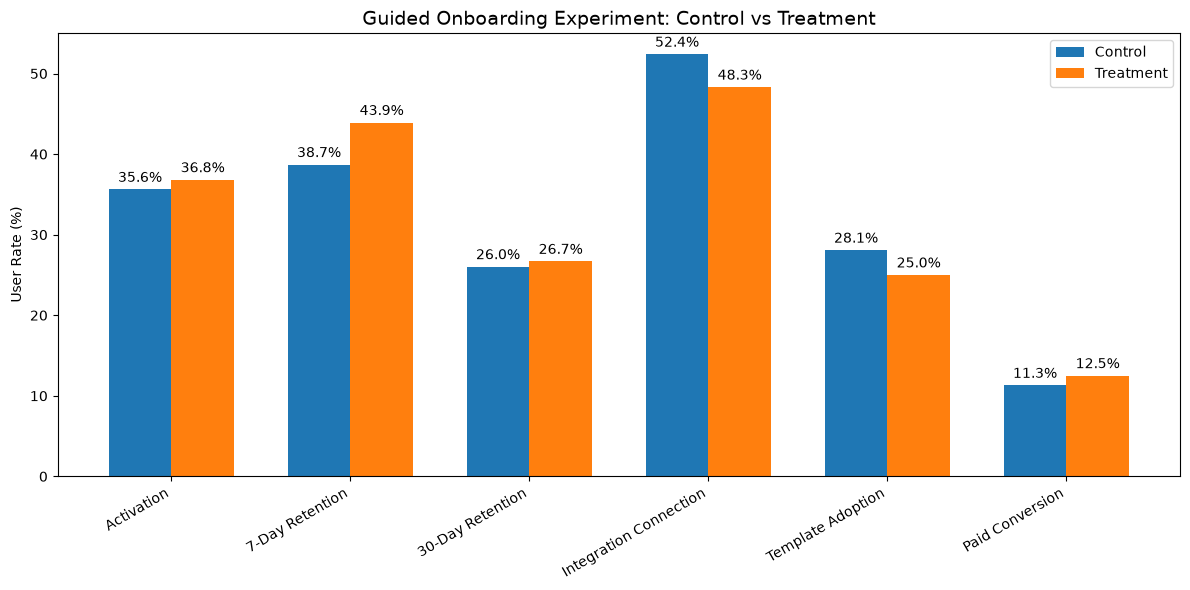

In [29]:
from pathlib import Path

# Select the main experiment metrics
plot_metrics = final_summary[
    final_summary["metric"].isin([
        "Activation",
        "7-Day Retention",
        "30-Day Retention",
        "Integration Connection",
        "Template Adoption",
        "Paid Conversion"
    ])
].copy()

x = np.arange(len(plot_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

control_bars = ax.bar(
    x - width / 2,
    plot_metrics["control_rate_pct"],
    width,
    label="Control"
)

treatment_bars = ax.bar(
    x + width / 2,
    plot_metrics["treatment_rate_pct"],
    width,
    label="Treatment"
)

ax.set_title(
    "Guided Onboarding Experiment: Control vs Treatment",
    fontsize=14
)

ax.set_ylabel("User Rate (%)")

ax.set_xticks(x)
ax.set_xticklabels(
    plot_metrics["metric"],
    rotation=30,
    ha="right"
)

ax.legend()

ax.bar_label(
    control_bars,
    fmt="%.1f%%",
    padding=3
)

ax.bar_label(
    treatment_bars,
    fmt="%.1f%%",
    padding=3
)

plt.tight_layout()

# Save the chart into the repo's images folder
project_root = Path.cwd().parent
images_dir = project_root / "images"

images_dir.mkdir(exist_ok=True)

output_path = images_dir / "guided_onboarding_experiment_results.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved to: {output_path.resolve()}")

plt.show()

## 9. Experiment Recommendation

The guided onboarding treatment produced mixed results.

### Key Findings

- **Activation:** increased from 35.62% to 36.82%  
  **+1.21 percentage points**

- **7-day retention:** increased from 38.70% to 43.92%  
  **+5.22 percentage points**

- **30-day retention:** increased from 26.03% to 26.69%  
  **+0.66 percentage points**

- **Paid conversion:** increased from 11.30% to 12.50%  
  **+1.20 percentage points**

However:

- Integration connection declined by **4.09 percentage points**
- Template adoption declined by **3.08 percentage points**
- No experiment metric reached statistical significance at the 5% level
- The 95% confidence interval for the 7-day retention effect ranged from **-2.73 to +13.17 percentage points**
- The experiment achieved only **25.07% statistical power**

### Recommendation

**Do not fully launch the treatment yet.**

The improvement in 7-day retention is promising, and the guardrail metrics did not show meaningful deterioration. However, the experiment was too small to determine whether the observed lift is statistically reliable.

The recommended next step is to run a larger follow-up experiment with approximately **1,395 users per group** if the goal is to detect an effect similar to the observed 7-day retention lift with 80% power.

This result should be treated as **promising but inconclusive**, rather than as evidence that the treatment definitively succeeded or failed.